# 5. Évaluation Complète des Modèles

**Projet Semesteriel - Détection de Fake News COVID-19**  
**Niveau 4CS | Superviseur : Prof. Salem Trabelsi**

---

## Objectif

Ce notebook fournit une évaluation exhaustive de tous les modèles :
- Rapports de classification détaillés
- Matrices de confusion
- Courbes ROC et AUC
- Courbes Précision-Rappel
- Coefficient de Matthews (MCC)
- Analyse des erreurs
- Tests de significativité statistique

## 5.1 Importation des bibliothèques

In [1]:
import os
import sys
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch.utils.data import DataLoader, Dataset

from transformers import (
    BertTokenizer, BertForSequenceClassification,
    DistilBertTokenizer, DistilBertForSequenceClassification
)

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    matthews_corrcoef, roc_auc_score
)
from sklearn.calibration import calibration_curve
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

sys.path.insert(0, os.path.join('..', 'src'))

In [2]:
print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


## 5.2 Chargement des modèles et des données

In [3]:
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
MODELS_DIR = os.path.join('..', 'models')

# Charger les données de test
df_test = pd.read_csv(os.path.join(PROCESSED_DIR, 'test_processed.csv'))

with open(os.path.join(PROCESSED_DIR, 'metadata.json'), 'r') as f:
    metadata = json.load(f)

label_names = list(metadata['label_mapping'].keys())
y_test = df_test['label_encoded'].values
texts_test = df_test['cleaned_text'].fillna('').values

print(f"Données de test : {len(df_test)} exemples")
print(f"Classes : {label_names}")

Données de test : 2140 exemples
Classes : ['fake', 'real']


In [4]:
# Charger les modèles baseline
baseline_models = {}
tfidf_vectorizer = None

# TF-IDF vectorizer
tfidf_path = os.path.join(MODELS_DIR, 'tfidf_vectorizer.pkl')
if os.path.exists(tfidf_path):
    with open(tfidf_path, 'rb') as f:
        tfidf_vectorizer = pickle.load(f)
    print("TF-IDF vectorizer chargé.")

TF-IDF vectorizer chargé.


In [5]:
# Charger chaque modèle baseline
for fname in os.listdir(MODELS_DIR):
    if fname.endswith('.pkl') and fname != 'tfidf_vectorizer.pkl':
        fpath = os.path.join(MODELS_DIR, fname)
        with open(fpath, 'rb') as f:
            model = pickle.load(f)
        model_name = fname.replace('.pkl', '').replace('_', ' ').title()
        baseline_models[model_name] = model
        print(f"Modèle baseline chargé : {model_name}")

Modèle baseline chargé : Logistic Regression


Modèle baseline chargé : Random Forest


Modèle baseline chargé : Svm Linearsvc


Modèle baseline chargé : Xgboost


In [6]:
# Prédictions baseline
baseline_predictions = {}
baseline_probas = {}

if tfidf_vectorizer is not None:
    X_test_tfidf = tfidf_vectorizer.transform(texts_test)
    
    for name, model in baseline_models.items():
        baseline_predictions[name] = model.predict(X_test_tfidf)
        if hasattr(model, 'predict_proba'):
            baseline_probas[name] = model.predict_proba(X_test_tfidf)
        elif hasattr(model, 'decision_function'):
            decision = model.decision_function(X_test_tfidf)
            # Convertir en pseudo-probabilités avec sigmoid
            from scipy.special import expit
            proba_pos = expit(decision)
            baseline_probas[name] = np.column_stack([1 - proba_pos, proba_pos])

print(f"\n{len(baseline_models)} modèles baseline chargés.")


4 modèles baseline chargés.


In [7]:
# Charger les modeles Transformer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]), max_length=self.max_length,
            truncation=True, padding='max_length',
            return_attention_mask=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

def get_transformer_predictions(model, tokenizer, texts, labels, device, batch_size=32, max_length=64):
    """Obtenir les predictions d'un modele Transformer."""
    dataset = FakeNewsDataset(texts, labels, tokenizer, max_length)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()
    all_preds = []
    all_probs = []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluation', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_probs)

transformer_predictions = {}
transformer_probas = {}

Device : cpu


In [8]:
# Charger BERT (si disponible)
bert_dir = os.path.join(MODELS_DIR, 'bert_best')
if os.path.exists(bert_dir):
    bert_tokenizer = BertTokenizer.from_pretrained(bert_dir)
    bert_model = BertForSequenceClassification.from_pretrained(bert_dir)
    bert_model = bert_model.to(device)
    preds, probs = get_transformer_predictions(bert_model, bert_tokenizer, texts_test, y_test, device)
    transformer_predictions['BERT'] = preds
    transformer_probas['BERT'] = probs
    print("BERT charge et evalue.")
else:
    print(f"BERT non trouve dans {bert_dir} - ignore.")

BERT non trouve dans ..\models\bert_best - ignore.


In [9]:
# Charger DistilBERT (si disponible)
db_dir = os.path.join(MODELS_DIR, 'distilbert_best')
if os.path.exists(db_dir):
    db_tokenizer = DistilBertTokenizer.from_pretrained(db_dir)
    db_model = DistilBertForSequenceClassification.from_pretrained(db_dir)
    db_model = db_model.to(device)
    preds, probs = get_transformer_predictions(db_model, db_tokenizer, texts_test, y_test, device)
    transformer_predictions['DistilBERT'] = preds
    transformer_probas['DistilBERT'] = probs
    print("DistilBERT charge et evalue.")
else:
    print(f"DistilBERT non trouve dans {db_dir} - ignore.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/67 [00:00<?, ?it/s]

DistilBERT charge et evalue.


In [10]:
# Combiner toutes les predictions
all_predictions = {**baseline_predictions, **transformer_predictions}
all_probas = {**baseline_probas, **transformer_probas}

print(f"\nModeles evalues : {list(all_predictions.keys())}")


Modeles evalues : ['Logistic Regression', 'Random Forest', 'Svm Linearsvc', 'Xgboost', 'DistilBERT']


## 5.3 Rapports de classification complets

In [11]:
for name, preds in all_predictions.items():
    print("=" * 60)
    print(f"RAPPORT DE CLASSIFICATION : {name}")
    print("=" * 60)
    print(classification_report(y_test, preds, target_names=label_names, digits=4))
    print()

RAPPORT DE CLASSIFICATION : Logistic Regression
              precision    recall  f1-score   support

        fake     0.4795    0.9186    0.6301      1020
        real     0.5538    0.0920    0.1577      1120

    accuracy                         0.4860      2140
   macro avg     0.5166    0.5053    0.3939      2140
weighted avg     0.5184    0.4860    0.3829      2140


RAPPORT DE CLASSIFICATION : Random Forest
              precision    recall  f1-score   support

        fake     0.4769    1.0000    0.6458      1020
        real     1.0000    0.0009    0.0018      1120

    accuracy                         0.4771      2140
   macro avg     0.7384    0.5004    0.3238      2140
weighted avg     0.7507    0.4771    0.3087      2140


RAPPORT DE CLASSIFICATION : Svm Linearsvc
              precision    recall  f1-score   support

        fake     0.4838    0.7755    0.5959      1020
        real     0.5465    0.2464    0.3397      1120

    accuracy                         0.4986     

## 5.4 Matrices de confusion côte à côte

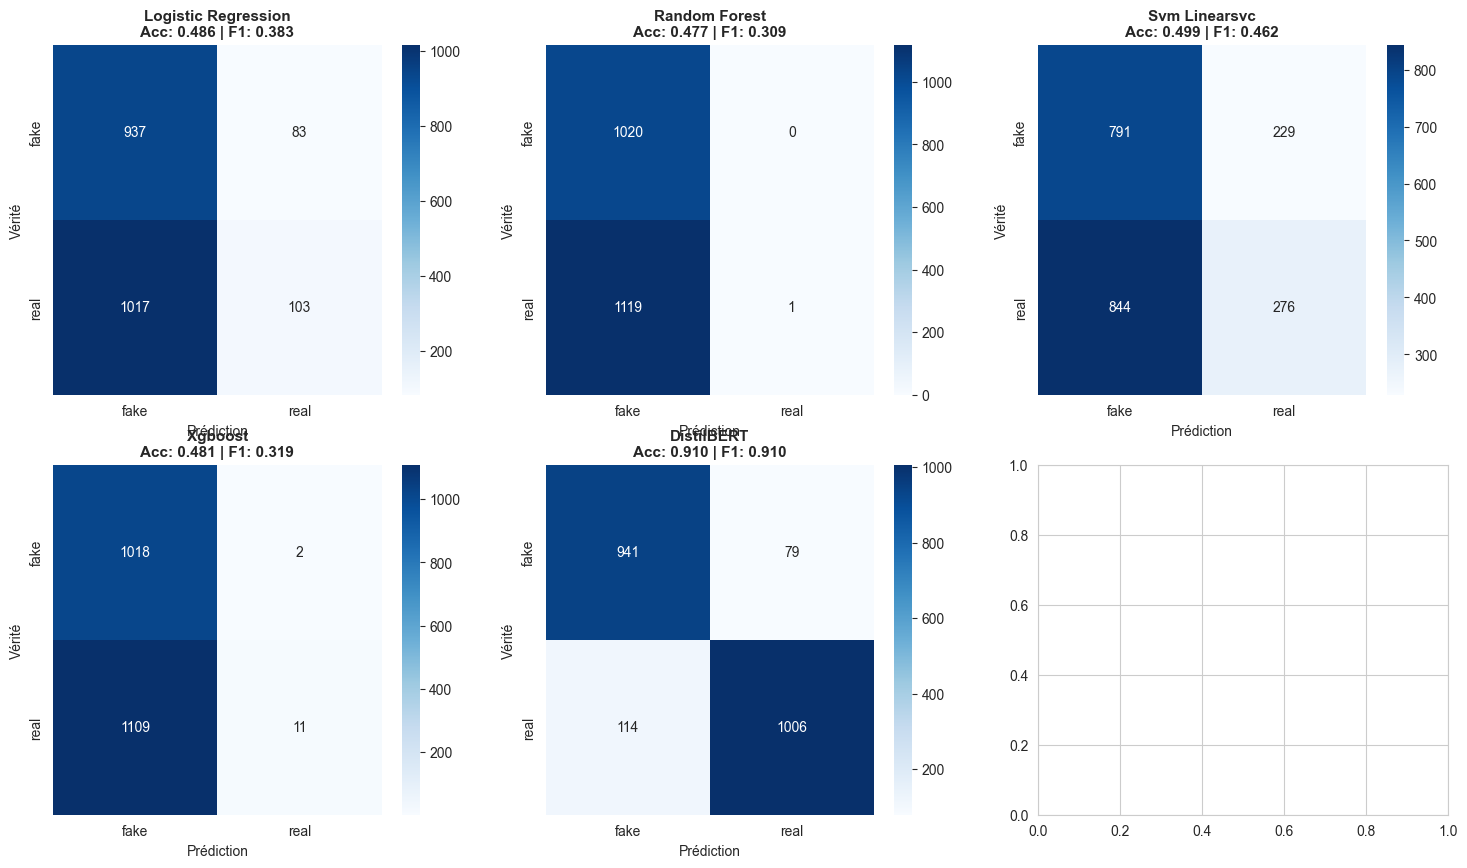

In [12]:
n_models = len(all_predictions)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
if n_models == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, (name, preds) in enumerate(all_predictions.items()):
    cm = confusion_matrix(y_test, preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=label_names, yticklabels=label_names,
        ax=axes[idx]
    )
    
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    axes[idx].set_title(f'{name}\nAcc: {acc:.3f} | F1: {f1:.3f}', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Prédiction')
    axes[idx].set_ylabel('Vérité')

In [13]:
# Cacher les axes inutilisés
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Matrices de confusion - Tous les modèles', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1200x600 with 0 Axes>

## 5.5 Courbes ROC et AUC

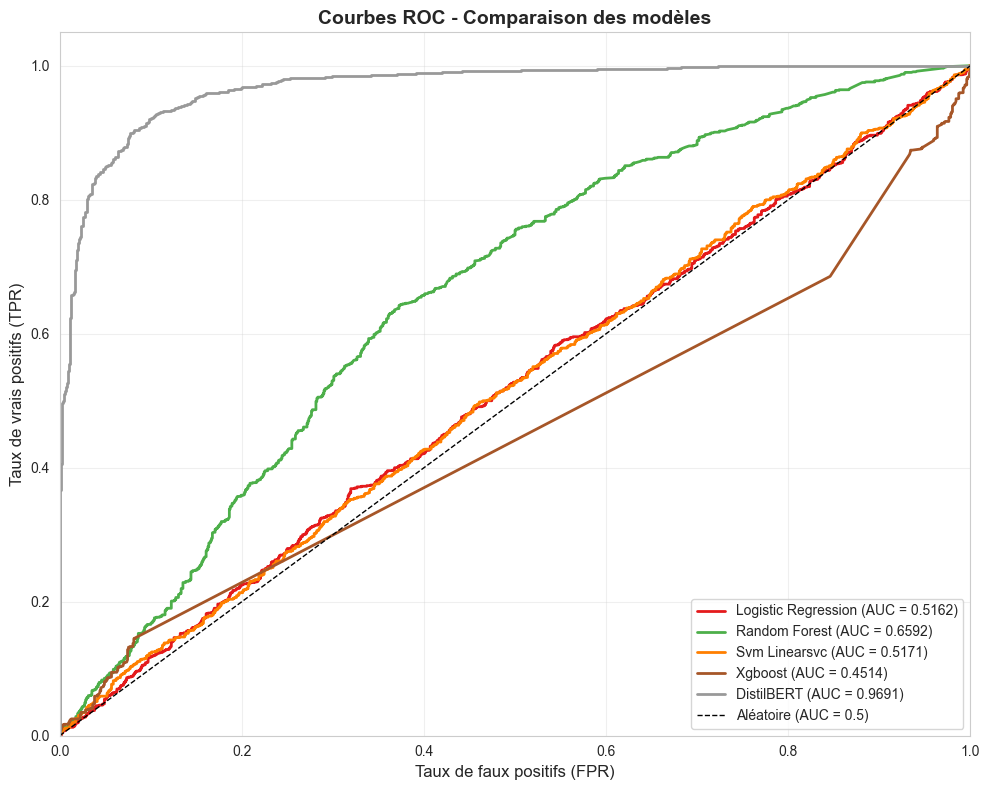

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

colors_list = plt.cm.Set1(np.linspace(0, 1, len(all_probas)))

for idx, (name, probs) in enumerate(all_probas.items()):
    if probs.ndim == 2 and probs.shape[1] >= 2:
        fpr, tpr, _ = roc_curve(y_test, probs[:, 1])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors_list[idx], linewidth=2,
                label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC = 0.5)')
ax.set_xlabel('Taux de faux positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de vrais positifs (TPR)', fontsize=12)
ax.set_title('Courbes ROC - Comparaison des modèles', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.6 Courbes Précision-Rappel

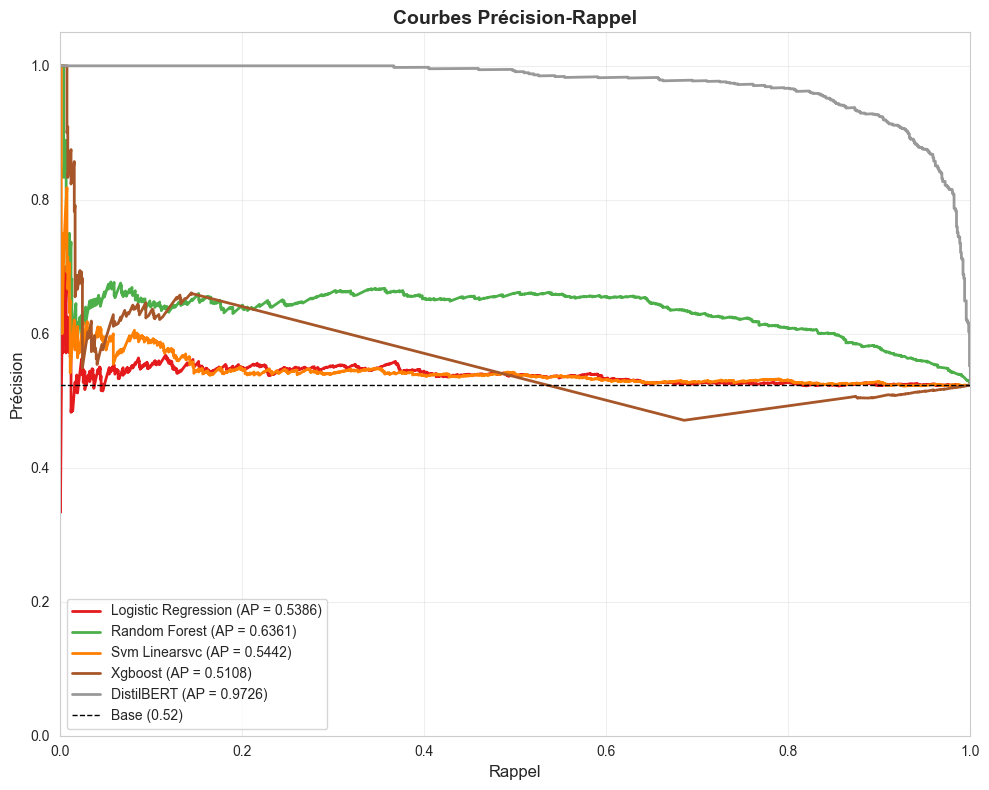

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))

for idx, (name, probs) in enumerate(all_probas.items()):
    if probs.ndim == 2 and probs.shape[1] >= 2:
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, probs[:, 1])
        ap = average_precision_score(y_test, probs[:, 1])
        ax.plot(recall_vals, precision_vals, color=colors_list[idx], linewidth=2,
                label=f'{name} (AP = {ap:.4f})')

# Ligne de base (proportion de positifs)
baseline_rate = y_test.mean()
ax.axhline(y=baseline_rate, color='k', linestyle='--', linewidth=1, label=f'Base ({baseline_rate:.2f})')

ax.set_xlabel('Rappel', fontsize=12)
ax.set_ylabel('Précision', fontsize=12)
ax.set_title('Courbes Précision-Rappel', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.7 Coefficient de Corrélation de Matthews (MCC)

In [16]:
print("=" * 60)
print("COEFFICIENT DE MATTHEWS (MCC)")
print("=" * 60)
print("\nLe MCC est une métrique équilibrée qui prend en compte")
print("les VP, VN, FP et FN. Valeurs de -1 à +1.")
print()

mcc_scores = {}
for name, preds in all_predictions.items():
    mcc = matthews_corrcoef(y_test, preds)
    mcc_scores[name] = mcc
    print(f"  {name:30s} | MCC: {mcc:.4f}")

COEFFICIENT DE MATTHEWS (MCC)

Le MCC est une métrique équilibrée qui prend en compte
les VP, VN, FP et FN. Valeurs de -1 à +1.

  Logistic Regression            | MCC: 0.0188
  Random Forest                  | MCC: 0.0206
  Svm Linearsvc                  | MCC: 0.0258
  Xgboost                        | MCC: 0.0505
  DistilBERT                     | MCC: 0.8199


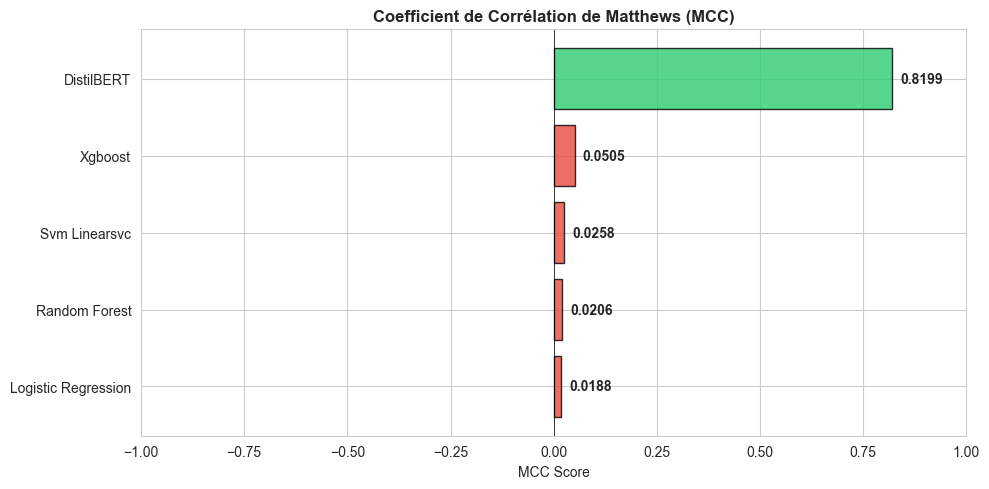

In [17]:
# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
names = list(mcc_scores.keys())
scores = list(mcc_scores.values())
colors_bar = ['#e74c3c' if s < 0.5 else '#f39c12' if s < 0.7 else '#2ecc71' for s in scores]

bars = ax.barh(names, scores, color=colors_bar, alpha=0.8, edgecolor='black')
ax.set_xlabel('MCC Score')
ax.set_title('Coefficient de Corrélation de Matthews (MCC)', fontweight='bold')
ax.set_xlim(-1, 1)
ax.axvline(x=0, color='black', linewidth=0.5)

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/mcc_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.8 Analyse des erreurs

### 5.8.1 Exemples mal classés

In [18]:
# Utiliser le meilleur modèle pour l'analyse des erreurs
best_model_name = max(all_predictions.keys(),
                       key=lambda k: f1_score(y_test, all_predictions[k], average='weighted'))
best_preds = all_predictions[best_model_name]
best_probs = all_probas.get(best_model_name)

print(f"Analyse des erreurs pour le meilleur modèle : {best_model_name}")
print(f"F1-Score : {f1_score(y_test, best_preds, average='weighted'):.4f}")

# Identifier les erreurs
errors_mask = best_preds != y_test
error_indices = np.where(errors_mask)[0]

print(f"\nNombre total d'erreurs : {len(error_indices)} / {len(y_test)} ({len(error_indices)/len(y_test)*100:.1f}%)")

# Types d'erreurs
false_positives = np.sum((best_preds == 1) & (y_test == 0))
false_negatives = np.sum((best_preds == 0) & (y_test == 1))
print(f"Faux positifs (predict real, vraiment fake) : {false_positives}")
print(f"Faux négatifs (predict fake, vraiment real) : {false_negatives}")

Analyse des erreurs pour le meilleur modèle : DistilBERT
F1-Score : 0.9099

Nombre total d'erreurs : 193 / 2140 (9.0%)
Faux positifs (predict real, vraiment fake) : 79
Faux négatifs (predict fake, vraiment real) : 114


In [19]:
# Afficher des exemples mal classés
print("=" * 60)
print("EXEMPLES MAL CLASSÉS")
print("=" * 60)

# Colonne de texte original
original_text_col = metadata.get('text_column', 'cleaned_text')
text_display_col = original_text_col if original_text_col in df_test.columns else 'cleaned_text'

n_examples = min(5, len(error_indices))
sample_errors = np.random.RandomState(42).choice(error_indices, n_examples, replace=False)

for idx in sample_errors:
    text = str(df_test.iloc[idx][text_display_col])[:300]
    true_label = label_names[y_test[idx]]
    pred_label = label_names[best_preds[idx]]
    
    confidence = ''
    if best_probs is not None:
        conf = best_probs[idx].max()
        confidence = f" (confiance: {conf:.3f})"
    
    print(f"\n--- Index {idx} ---")
    print(f"Vrai : {true_label} | Prédit : {pred_label}{confidence}")
    print(f"Texte : {text}...")

EXEMPLES MAL CLASSÉS

--- Index 479 ---
Vrai : fake | Prédit : real (confiance: 0.969)
Texte : BREAKING! Families of NHS workers who die of covid-19 to be offered £60k compensation or a couple of thousand sets of PPE that we'll have by then...

--- Index 1607 ---
Vrai : real | Prédit : fake (confiance: 0.875)
Texte : Its role in coronavirus severity made #VitaminD this week's top clinical trend. https://t.co/oJ2gKKhEMW https://t.co/cVqDYe7LsB...

--- Index 861 ---
Vrai : fake | Prédit : real (confiance: 0.771)
Texte : Countries were exporting COVID-19 “diagnostic test instruments” in 2018....

--- Index 1727 ---
Vrai : real | Prédit : fake (confiance: 0.605)
Texte : Weighing risk vs reward on human challenge trials for coronavirus vaccine. https://t.co/5suYDGbpyK ⚖️...

--- Index 1255 ---
Vrai : real | Prédit : fake (confiance: 0.881)
Texte : Still not enough proof that convalescent plasma works with COVID-19. https://t.co/CJk2tklGqq...


### 5.8.2 Analyse des patterns d'erreurs

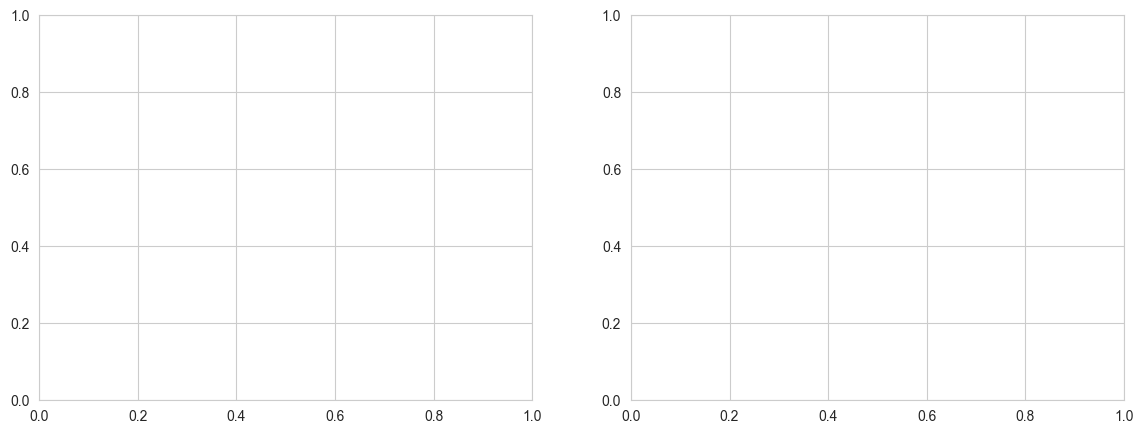

In [20]:
# Analyser les caractéristiques des textes bien classés vs mal classés
df_test['prediction'] = best_preds
df_test['correct'] = (best_preds == y_test)
df_test['text_length_chars'] = df_test['cleaned_text'].astype(str).apply(len)
df_test['text_word_count'] = df_test['cleaned_text'].astype(str).apply(lambda x: len(x.split()))

# Comparer les longueurs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [21]:
# Longueur des textes
correct_df = df_test[df_test['correct']]
incorrect_df = df_test[~df_test['correct']]

axes[0].hist(correct_df['text_length_chars'], bins=40, alpha=0.6, label='Correct', color='#2ecc71')
axes[0].hist(incorrect_df['text_length_chars'], bins=40, alpha=0.6, label='Incorrect', color='#e74c3c')
axes[0].set_title('Longueur des textes : corrects vs incorrects', fontweight='bold')
axes[0].set_xlabel('Nombre de caractères')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

In [22]:
# Nombre de mots
axes[1].hist(correct_df['text_word_count'], bins=40, alpha=0.6, label='Correct', color='#2ecc71')
axes[1].hist(incorrect_df['text_word_count'], bins=40, alpha=0.6, label='Incorrect', color='#e74c3c')
axes[1].set_title('Nombre de mots : corrects vs incorrects', fontweight='bold')
axes[1].set_xlabel('Nombre de mots')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/error_analysis_length.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1200x600 with 0 Axes>

In [23]:
# Statistiques
print(f"Longueur moyenne (correct)   : {correct_df['text_length_chars'].mean():.0f} caractères")
print(f"Longueur moyenne (incorrect) : {incorrect_df['text_length_chars'].mean():.0f} caractères")

Longueur moyenne (correct)   : 159 caractères
Longueur moyenne (incorrect) : 148 caractères


### 5.8.3 Analyse de la confiance des prédictions

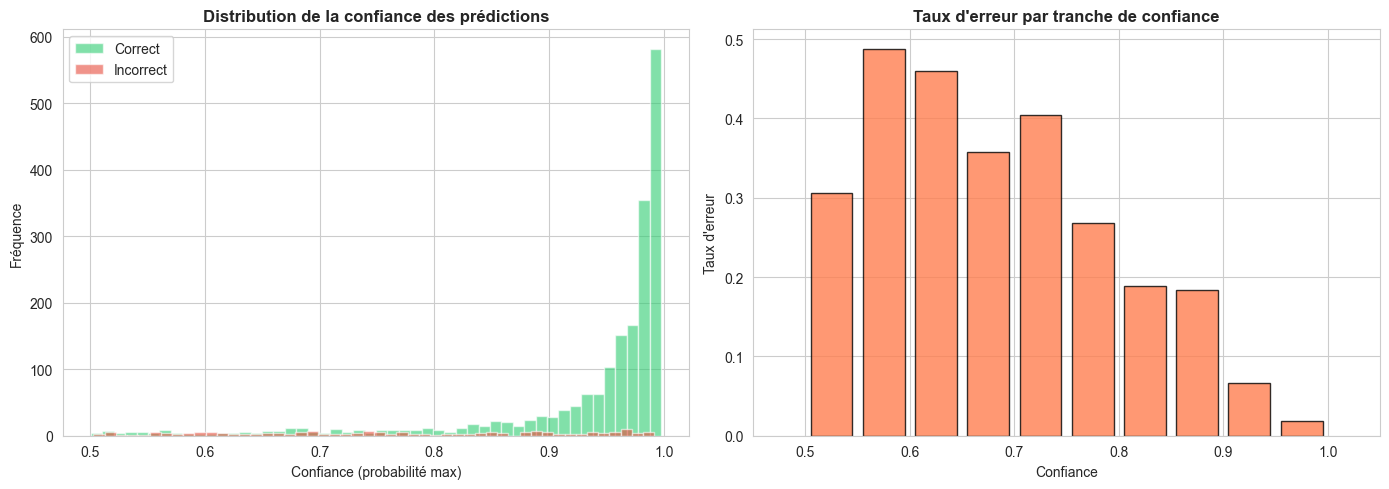

Confiance moyenne (correct)   : 0.9346
Confiance moyenne (incorrect) : 0.7659


In [24]:
if best_probs is not None:
    max_probs = best_probs.max(axis=1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution de confiance globale
    axes[0].hist(max_probs[df_test['correct']], bins=50, alpha=0.6, label='Correct', color='#2ecc71')
    axes[0].hist(max_probs[~df_test['correct']], bins=50, alpha=0.6, label='Incorrect', color='#e74c3c')
    axes[0].set_title('Distribution de la confiance des prédictions', fontweight='bold')
    axes[0].set_xlabel('Confiance (probabilité max)')
    axes[0].set_ylabel('Fréquence')
    axes[0].legend()
    
    # Taux d'erreur par tranche de confiance
    bins = np.arange(0.5, 1.05, 0.05)
    error_rates = []
    bin_centers = []
    for i in range(len(bins) - 1):
        mask = (max_probs >= bins[i]) & (max_probs < bins[i+1])
        if mask.sum() > 0:
            error_rate = (~df_test['correct'].values[mask]).mean()
            error_rates.append(error_rate)
            bin_centers.append((bins[i] + bins[i+1]) / 2)
    
    axes[1].bar(bin_centers, error_rates, width=0.04, color='coral', alpha=0.8, edgecolor='black')
    axes[1].set_title('Taux d\'erreur par tranche de confiance', fontweight='bold')
    axes[1].set_xlabel('Confiance')
    axes[1].set_ylabel('Taux d\'erreur')
    axes[1].set_xlim(0.45, 1.05)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/confidence_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Confiance moyenne (correct)   : {max_probs[df_test['correct'].values].mean():.4f}")
    print(f"Confiance moyenne (incorrect) : {max_probs[~df_test['correct'].values].mean():.4f}")
else:
    print("Pas de probabilités disponibles pour l'analyse de confiance.")

## 5.9 Tests de significativité statistique

Nous utilisons le test de McNemar pour vérifier si les différences de performance entre modèles sont statistiquement significatives.

In [25]:
from itertools import combinations

def mcnemar_test(y_true, preds_a, preds_b):
    """Test de McNemar pour comparer deux classifieurs."""
    correct_a = (preds_a == y_true)
    correct_b = (preds_b == y_true)
    
    # Tableau de contingence
    b_correct_a_wrong = np.sum(correct_b & ~correct_a)  # b correct, a faux
    a_correct_b_wrong = np.sum(correct_a & ~correct_b)  # a correct, b faux
    
    # Test de McNemar (avec correction de continuité)
    n = b_correct_a_wrong + a_correct_b_wrong
    if n == 0:
        return 0.0, 1.0  # Pas de différence
    
    chi2 = (abs(b_correct_a_wrong - a_correct_b_wrong) - 1) ** 2 / n
    p_value = 1 - stats.chi2.cdf(chi2, df=1)
    
    return chi2, p_value

In [26]:
print("=" * 70)
print("TESTS DE McNEMAR (significativité statistique)")
print("=" * 70)
print(f"{'Modèle A':25s} vs {'Modèle B':25s} | Chi2     | p-value   | Significatif?")
print("-" * 90)

model_names = list(all_predictions.keys())
for name_a, name_b in combinations(model_names, 2):
    chi2, p_value = mcnemar_test(y_test, all_predictions[name_a], all_predictions[name_b])
    sig = "OUI ***" if p_value < 0.001 else "OUI **" if p_value < 0.01 else "OUI *" if p_value < 0.05 else "NON"
    print(f"{name_a:25s} vs {name_b:25s} | {chi2:8.3f} | {p_value:9.6f} | {sig}")

TESTS DE McNEMAR (significativité statistique)
Modèle A                  vs Modèle B                  | Chi2     | p-value   | Significatif?
------------------------------------------------------------------------------------------
Logistic Regression       vs Random Forest             |    1.751 |  0.185707 | NON
Logistic Regression       vs Svm Linearsvc             |    2.042 |  0.152979 | NON
Logistic Regression       vs Xgboost                   |    0.565 |  0.452264 | NON
Logistic Regression       vs DistilBERT                |  769.293 |  0.000000 | OUI ***
Random Forest             vs Svm Linearsvc             |    4.018 |  0.045021 | OUI *
Random Forest             vs Xgboost                   |    4.083 |  0.043308 | OUI *
Random Forest             vs DistilBERT                |  789.322 |  0.000000 | OUI ***
Svm Linearsvc             vs Xgboost                   |    2.749 |  0.097316 | NON
Svm Linearsvc             vs DistilBERT                |  748.683 |  0.000000 | OUI 

## 5.10 Tableau récapitulatif complet

In [27]:
# Tableau récapitulatif avec toutes les métriques
final_results = []

for name, preds in all_predictions.items():
    row = {
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds, average='weighted'),
        'Précision': precision_score(y_test, preds, average='weighted'),
        'Rappel': recall_score(y_test, preds, average='weighted'),
        'MCC': matthews_corrcoef(y_test, preds),
    }
    
    if name in all_probas:
        probs = all_probas[name]
        if probs.ndim == 2 and probs.shape[1] >= 2:
            row['AUC-ROC'] = roc_auc_score(y_test, probs[:, 1])
            row['AP'] = average_precision_score(y_test, probs[:, 1])
    
    final_results.append(row)

final_df = pd.DataFrame(final_results)

In [28]:
print("=" * 100)
print("TABLEAU RÉCAPITULATIF COMPLET")
print("=" * 100)
print(final_df.to_string(index=False, float_format='%.4f'))

# Sauvegarder
final_df.to_csv(os.path.join(MODELS_DIR, 'evaluation_results.csv'), index=False)
print(f"\nRésultats sauvegardés dans {os.path.join(MODELS_DIR, 'evaluation_results.csv')}")

TABLEAU RÉCAPITULATIF COMPLET
             Modèle  Accuracy  F1-Score  Précision  Rappel    MCC  AUC-ROC     AP
Logistic Regression    0.4860    0.3829     0.5184  0.4860 0.0188   0.5162 0.5386
      Random Forest    0.4771    0.3087     0.7507  0.4771 0.0206   0.6592 0.6361
      Svm Linearsvc    0.4986    0.4618     0.5166  0.4986 0.0258   0.5171 0.5442
            Xgboost    0.4808    0.3185     0.6710  0.4808 0.0505   0.4514 0.5108
         DistilBERT    0.9098    0.9099     0.9104  0.9098 0.8199   0.9691 0.9726

Résultats sauvegardés dans ..\models\evaluation_results.csv


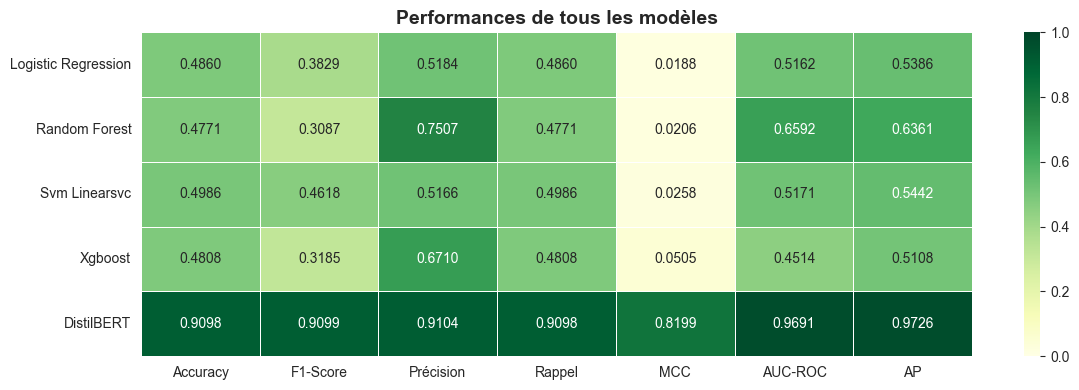

In [29]:
# Visualisation du tableau final en heatmap
metric_cols = [c for c in final_df.columns if c != 'Modèle']
plot_data = final_df.set_index('Modèle')[metric_cols]

fig, ax = plt.subplots(figsize=(12, max(4, len(plot_data) * 0.8)))
sns.heatmap(
    plot_data.astype(float), annot=True, fmt='.4f', cmap='YlGn',
    linewidths=0.5, ax=ax, vmin=0, vmax=1
)
ax.set_title('Performances de tous les modèles', fontsize=14, fontweight='bold')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/figures/final_results_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.11 Discussion sur la robustesse cross-domaine

### Considérations importantes :

1. **Généralisation** : Le modèle a été entraîné sur des données spécifiques au COVID-19. Sa capacité à détecter des fake news sur d'autres sujets reste à vérifier.

2. **Évolution temporelle** : Les fake news évoluent dans le temps. Un modèle entraîné sur des données de 2020-2021 pourrait ne pas détecter les nouvelles stratégies de désinformation.

3. **Biais linguistiques** : Le modèle ne fonctionne qu'en anglais. Pour d'autres langues, un modèle multilingue (mBERT, XLM-R) serait nécessaire.

4. **Attaques adversariales** : Le modèle pourrait être vulnérable à des textes spécialement conçus pour le tromper (paraphrase, ajout de mots clés).

### Recommandations :
- Tester sur des datasets externes de vérification de faits
- Mettre à jour régulièrement le modèle avec de nouvelles données
- Combiner avec d'autres signaux (métadonnées, réseau social)

In [30]:
# Nettoyage
df_test = df_test.drop(columns=['prediction', 'correct', 'text_length_chars', 'text_word_count'], errors='ignore')

if device.type == 'cuda':
    torch.cuda.empty_cache()

print("Évaluation terminée.")
print("Passez au notebook 06_explainability.ipynb pour l'analyse d'explicabilité.")

Évaluation terminée.
Passez au notebook 06_explainability.ipynb pour l'analyse d'explicabilité.
